In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
import datetime
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


## EPS 88 Final Project - Fall 2024

### Introductory Text:
I’ve always been fascinated by outer space— stars, planets, the sun, black holes, and everything that is unlike here. When I chose to pursue Data Science, one of my goals was to apply data analysis tools to topics I’m already interested in in order to truly make a connection and enhance my understanding. I knew from the moment I started EPS 88 that I wanted to focus my final project on a concept that concerned both Earth Science and Astronomy. For this particular project, I will be focusing on how the Sun and space weather interact with Earth, and investigating the relationship between solar cycles and the geomagnetic activity that affects our technology.

I will be using the Sun’s 11-year solar cycle to identify key periods where solar activity is highest, lowest, what an ‘average’ solar cycle looks like, and establishing key dates and cycle time frames. I will cross reference these periods with existing data about space weather—specifically sunspots, and geomagnetic activity. This is key for understanding the nature of space weather and establishing a framework for how and when these effects occur.

I will attempt to back up the relationship between sunspots and their subsequent increased solar activity, and electromagnetic activity that results from it. My visualization methods will include scatter plots and line plots, and data methods will include correlation and feature lagging. 


The following are the data sets that were utilized in this project, listed by *NAME: SOURCE(FILENAME)*:
 
- ISES Solar Cycle Sunspot Number Progression: https://www.swpc.noaa.gov/products/solar-cycle-progression (solar_cycle.json)

- German Research Centre for Geoscience (GFZ) Geomagnetic and solar indices (Kp, ap, Ap, SN, F10.7): https://kp.gfz-potsdam.de/en/data (geomagnetic_solar_indices.txt) 


## Space Weather + The Sun:
Space weather, according to the National Oceanic and Atmospheric Administration (NOAA)’s Space Weather Prediction Center, refers to “variations in the space environment between the sun and Earth (and throughout the solar system) that can affect technologies in space and on Earth. Space weather is primarily driven by solar storm phenomenon that include coronal mass ejections, solar flares, solar particle events and solar wind.” (https://www.swpc.noaa.gov/content/education-and-outreach)

#### Solar Cycle 
The 11-year Solar Magnetic Activity Cycle of the Sun (Schwabe cycle), refers to the phenomena where the Sun’s magnetic poles flip every 11 years, resulting in fluctuating magnetic activity. This cycle has a solar minimum, where this activity is at its lowest, and a solar maximum, where the Sun is at peak-activity; including increased CMEs, solar flares, and magnetic disturbances. Understanding and predicting this cycle is a challenge within astrophysics, however, it’s important to understand how Earth is affected, and to anticipate fluctuations in it’s behavior. 

#### Sunspots
Sunspots are darker, cooler spots on the Sun’s photosphere that occur due to concentrated disruption of its magnetic fields. Sunspots tend to occur most in the active regions of the Sun’s surface, where strong magnetic fields interact with the Sun’s atmosphere the most. Sunspots can lead to CMEs, solar flares, and solar storms. They vary in size and darkness, and their frequency depends on the 11-year solar cycle. (NOAA Sunspots) Keeping track of these sunspots is what enables us to keep track of the Sun's solar cycle.

The following graph shows NOAA's ISES Solar Cycle Sunspot Number Progression data set, which tracks the number of sunspots over time. The data points form an oscillating pattern, where each 11-year cycle is measured from dip to dip or hill to hill. The dips indicate the solar minimums in the cycle, while the hills indicate the solar maximums. An increase in sunspots can lead to an increase in solar activity since they're closely related, indicating time periods of interest.

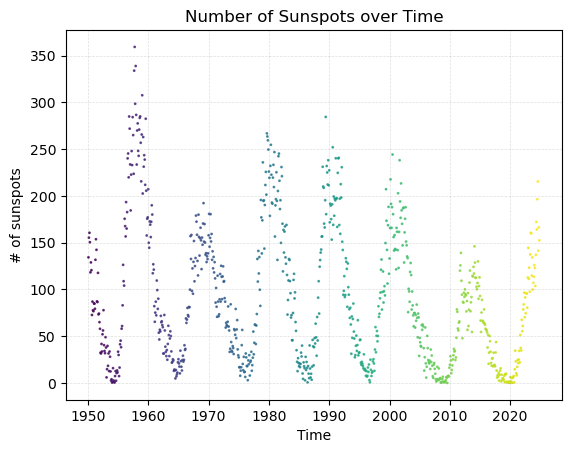

In [4]:
# Reading the database + assigning a name
SC = pd.read_json('data/solar_cycle.json')

# Convert to datetime format
SC['time-tag'] = pd.to_datetime(SC['time-tag'])

# Filter by date
solar_cycle = SC.loc[SC['time-tag'] > '1950-01-01']

# Assign name to column variables, set color and size
time = solar_cycle['time-tag']
sunspot_num = solar_cycle['ssn']
radio_flux = solar_cycle['f10.7']
colors = np.arange(len(solar_cycle))
sizes = 1

# Create scatter plot with # of sunspots over time, grid, labels, and title
plt.scatter(time, sunspot_num, c=colors, s=sizes, alpha=0.80)
plt.grid(color = 'grey', linestyle = '--', linewidth = 0.5, alpha=0.25)
plt.xlabel('Time')
plt.ylabel('# of sunspots')
plt.title('Number of Sunspots over Time')
plt.show()


The Sun’s activity is what primarily causes space weather. Phenomena include Coronal Mass Ejections (CMEs), solar flares, and geomagnetic storms.

Coronal Mass Ejections (CMEs) are bursts of plasma and magnetic fields that are ejected from the Sun’s corona and look like a twisted rope called a “flux rope”. Although not necessary for CMEs, they are often associated with solar flares (JPL-NASA). Solar flares are explosions on the Sun’s surface, which “occur when large, looming coronal loops or filaments (similar to iron filings]) are buffeted or disturbed in some way. (NSO) These bursts expulse electromagnetic radiation, and are often associated with sunspots. It's this electromagnetic radiation and geomagnetic activity that interferes with radio and satellite signals.


The following data set is the German Research Centre for Geosciences' Geomagnetic/Solar Indices dataset (https://kp.gfz-potsdam.de/en/data). This data includes Kp (Planetary Index) and Ap (Planetary Amplitude), which are useful in analyzing geomagnetic activity, .

The YYYY-MM-DD columns are self explanatory, enabling time and date alignments.

The Kp1 - Kp8 columns refer to kp-index values, the primary measure of **geomagnetic activity**-- higher Kp values equate to greater geomagnetic disturbances. These range across eight 3-hour intervals.

The Ap column refers to daily planetary amplitude, measuring the average Kp-based ap values ranging from ap1 to ap8. This measure indicates **overall geomagnetic activity** for the day.

The SN column refers to the international sunspot number, which are associated with solar activity as seen with the NOAA Solar Cycle progression. 

The F10.7obs and F10.7adj columns refer to Solar Radio Flux. The flux at wavelength 10.7 is used to measure solar activity, and it correlates to solar irradiance (how much solar energy is reaching the upper atmosphere and ionosphere). The F10.7adj column is an adjusted version of this column  that aims to improve accuracy by taking into account other factors.

The D column is a data status flag, which measures the reliability of the KP and SN values. 
- D=0: Kp and SN values are in progress
- D=1: Kp values are final, but SN values are in progress
- D=2: Both Kp and SN values are final.

I will be using the Kp and Ap columns to evaluate geomagnetic activity which affects satellites, GPS systems, and power grids. I'll use the F10.7 column to evaluate the solar radiation influence on the ionosphere, which affects radio and navigation systems.


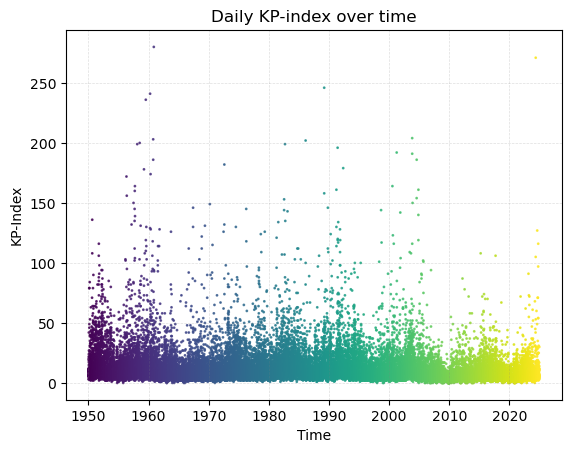

In [9]:
# The kp_index dataset is a .txt file

#I set the column widths and compare them to the alignment on the .txt file format to ensure correct columns
column_widths = [
    4,   # Year
    4,   # Month
    2,   # Day
    6,   # Days
    8,   # Days_m
    5,   # BSR
    4,   # dB
    6,   # Kp1
    7,   # Kp2
    8,   # Kp3
    8,   # Kp4
    7,   # Kp5
    7,   # Kp6
    7,   # Kp7
    7,   # Kp8
    5,   # ap1
    5,   # ap2
    5,   # ap3
    5,   # ap4
    5,   # ap5
    5,   # ap6
    5,   # ap7
    5,   # ap8
    5,   # AP
    7,   # SN
    7,   # F10.7obs
    7,   # F10.7adj
    3    # D
]
# Defining column names
column_names = [
    'Year', 'Month', 'Day', 'Days', 'Days_m', 'BSR', 'dB', 'Kp1', 'Kp2', 'Kp3', 'Kp4', 'Kp5', 
    'Kp6', 'Kp7', 'Kp8', 'ap1', 'ap2', 'ap3', 'ap4', 'ap5', 'ap6', 'ap7', 'ap8', 'AP', 'SN', 
    'F10.7obs', 'F10.7adj', 'D'
]

kp_index = pd.read_fwf('data/geomagnetic_solar_indices.txt',  widths=column_widths, header=None, names=column_names, skipinitialspace=True)

# Since this data set already looks at the 1950 - Present timeframe, I convert to datetime format
kp_index['time-tag'] = pd.to_datetime(kp_index[['Year','Month','Day']])
kp_index = kp_index.drop(['Year', 'Month','Day'], axis=1)

# Assign name to column variables, set color and size
date = kp_index['time-tag']
daily_kp = kp_index['AP']
solar_radio_flux = kp_index['F10.7adj']
colors = np.arange(len(kp_index))
sizes = 1

# Create scatter plot with # of sunspots over time, grid, labels, and title
plt.scatter(date, daily_kp, c=colors, s=sizes, alpha=0.80, label='Daily Kp (AP)')
plt.grid(color = 'grey', linestyle = '--', linewidth = 0.5, alpha=0.25,)
plt.xlabel('Time')
plt.ylabel('KP-Index')
plt.title('Daily KP-index over time')
plt.show()



My first data method/approach is a straight-foward correlation function. This correlation method will help us understand how sunspots and increased solar activity correlates to geomagnetic activity detected from Earth and solar radio flux.

In [10]:
sunspot_geomagnetic_merged = pd.merge(solar_cycle, kp_index, on='time-tag')
sunspot_geomagnetic_merged.head()

correlation, p_value = pearsonr(sunspot_geomagnetic_merged['SN'], sunspot_geomagnetic_merged ['AP'])
print(f"Correlation: {correlation}, P-Value: {p_value}")


Correlation: 0.17425960647144625, P-Value: 1.4805724755038746e-07


The correlation between sunspot numbers and seems to be insignificant as per the correlation and p-value.
**However**, when looking at the plots, it's evident that there is a correlation between when solar maximum peaks and when geomagnetic activity peaks. When looking at the kp-index dataset, there is a constant concetration of data below a kp-index of 50, where the significant patterns appear above that threshold. Could it be that these data points are dilluting the overall relationship between these two factors?

Below, I excluded AP values above 50, and ran the same correlation calculation.

In [13]:
merged_above_50 = sunspot_geomagnetic_merged[sunspot_geomagnetic_merged['AP'] > 50]

correlation, p_value = pearsonr(merged_above_50['SN'], merged_above_50['AP'])
print(f"Correlation: {correlation}, P-Value: {p_value}")

Correlation: 0.15490235100721564, P-Value: 0.48035284583573606


Although a little better, the relationship isn't quite as strong as expected. This could be due to a variety of factors, including a potential time lag. I will try to address this unexpected outcome with a linear regression model in an attempt to use existing sunspot data to predict geomagnetic activity on a short time-scale (https://scikit-learn.org/1.5/auto_examples/applications/plot_time_series_lagged_features.html)

In [14]:
# Create lagged features (lag of 1, 2, and 3 days for example)
merged_above_50 = merged_above_50.copy()

merged_above_50['SN_lag1'] = merged_above_50['SN'].shift(1)
merged_above_50['SN_lag2'] = merged_above_50['SN'].shift(2)
merged_above_50['SN_lag3'] = merged_above_50['SN'].shift(3)

# Drop rows with NaN values that were created due to the lag shift
merged_above_50 = merged_above_50.dropna()

# Preview the data to see the lagged features
print(merged_above_50.head())

      time-tag    ssn  smoothed_ssn  observed_swpc_ssn  smoothed_swpc_ssn  \
31  1952-09-01   40.4          40.3               -1.0               -1.0   
89  1957-07-01  265.1         271.1               -1.0               -1.0   
100 1958-06-01  242.9         264.5               -1.0               -1.0   
122 1960-04-01  172.7         169.4               -1.0               -1.0   
130 1960-12-01  121.2         118.5               -1.0               -1.0   

     f10.7  smoothed_f10.7   Days   Days_m   BSR  ...  ap7  ap8   AP   SN  \
31    -1.0            -1.0   7549   7549.5  1631  ...   27   67   51  126   
89    -1.0            -1.0   9313   9313.5  1697  ...  132   48   83  262   
100   -1.0            -1.0   9648   9648.5  1709  ...   48   32   60  283   
122   -1.0            -1.0  10318  10318.5  1734  ...  300  154  241  218   
130   -1.0            -1.0  10562  10562.5  1743  ...   67   80   93  105   

     F10.7obs  F10.7adj  D  SN_lag1  SN_lag2  SN_lag3  
31       -1.0     

I then applied the same correlation function to the feature lagged data set;

In [17]:
correlation, p_value = pearsonr(merged_above_50['SN'], merged_above_50['AP'])
print(f"Correlation: {correlation}, P-Value: {p_value}")

Correlation: 0.07737928546588191, P-Value: 0.745744800666953


## Conclusion

# Results
Overall, the results are not very significant, despite the logical correlation between hightened sunspot amounts and subsuquent geomagnetic activity which results from phenomena like CMEs and solar flares. I was suprised that although both of the graphs show correlating increases in space weather activity-- similar time frames and a similar oscellating fashion-- the correlation vaue and p-values weren't promising, even after lagging some of the features. 
I had some trouble finding substansive data on Earth techology and had to figure out how to compile seperate NOAA data files into one. If I could do this project again, I would place more emphasis on finding data, whether clean, or in need of scraping.

# Next Steps
This project was cut short due to the semester coming to an end (and being a bit too ambitious). However, this is only the start. I want to keep investigating the correlation between space weather and Earth, and have many ideas on concepts I want to cover. These include power grid activity in correlation to space weather, the relationship between solar panels and solar activity, and how climate change is impacting our main protector from space weather-- the atmosphere (namely the ionosphere). I want to also apply polynomial regression to my existing data sets, and figure out what other factors are contributing to such an unexpectantly poor correlation.? 


## Acknowledgements and Works Cited

**Data Sets:**
- ISES Solar Cycle Sunspot Number Progression: https://www.swpc.noaa.gov/products/solar-cycle-progression (solar_cycle.json)
- German Research Centre for Geoscience (GFZ) Geomagnetic and solar indices (Kp, ap, Ap, SN, F10.7): https://kp.gfz-potsdam.de/en/data (geomagnetic_solar_indices.txt) 

**Works Cited**
- JPL-NASA: https://www.jpl.nasa.gov/nmp/st5/SCIENCE/cme.html
- National Solar Observatory (NSO): https://nso.edu/for-public/sun-science/coronal-mass-ejections-cme/
- NASA Sunspots: https://science.nasa.gov/sun/sunspots/
- NOAA: https://www.swpc.noaa.gov/content/education-and-outreach
- Lagged Features: https://scikit-learn.org/1.5/auto_examples/applications/plot_time_series_lagged_features.html

Additionally I want to thank ChatGPT and the creators behind it. While it can certainly be abused, it can also be an excellent learning tool. Without much data analysis exprience, questions about the smallest things, syntaxes, error messages, and application confusions arise, and ChatGPT is excellent for on-demand debugging, brainstorming, and explanation of concepts.ures.html